In [ ]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Tesla - Deaths.csv to Tesla - Deaths.csv


In [ ]:
data = pd.read_csv("Tesla - Deaths.csv")

In [ ]:
data

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [ ]:
data.isna().sum()

,0
Case #,13
Year,13
Date,13
Country,13
State,13
Description,12
Deaths,8
Tesla driver,13
Tesla occupant,17
Other vehicle,12


In [ ]:
data.shape

(307, 24)

In [ ]:
drop_columns = ['Case #','Year', 'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',

       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 ']

data.drop(columns = drop_columns, inplace = True)

In [ ]:
data.shape

(307, 14)

In [ ]:
data[' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO '].value_counts()

,count
Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,
-,269
1,21
2,3
3,1
24,1
27,1


In [ ]:
data.drop(columns = ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ', inplace = True)



In [ ]:
cols = data.columns[5:]

for col in cols:

  if col != ' Model ':

    print(col)

    data[col] = data[col].fillna("-")

    data[col] = data[col].str.strip()

    data[col] = data[col].replace("-", "0")

    data[col] = data[col].astype(int)

    #print(data[col].unique())

 Tesla driver 
 Tesla occupant 
 Other vehicle 
 Cyclists/ Peds 
 TSLA+cycl / peds 
 Autopilot claimed 
 Verified Tesla Autopilot Deaths 


In [ ]:
data.head()

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               294 non-null    object 
 1    Country                           294 non-null    object 
 2    State                             294 non-null    object 
 3    Description                       295 non-null    object 
 4    Deaths                            299 non-null    float64
 5    Tesla driver                      307 non-null    int64  
 6    Tesla occupant                    307 non-null    int64  
 7    Other vehicle                     307 non-null    int64  
 8    Cyclists/ Peds                    307 non-null    int64  
 9    TSLA+cycl / peds                  307 non-null    int64  
 10   Model                             296 non-null    object 
 11   Autopilot claimed                 307 non-null    int64  

In [ ]:
data.isna().sum()

,0
Date,13
Country,13
State,13
Description,12
Deaths,8
Tesla driver,0
Tesla occupant,0
Other vehicle,0
Cyclists/ Peds,0
TSLA+cycl / peds,0


In [ ]:
data.dropna(inplace = True)

In [ ]:
data.isna().sum()

,0
Date,0
Country,0
State,0
Description,0
Deaths,0
Tesla driver,0
Tesla occupant,0
Other vehicle,0
Cyclists/ Peds,0
TSLA+cycl / peds,0


In [ ]:
data.shape

(294, 13)

In [ ]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

In [ ]:
data.columns = data.columns.str.strip()

data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla driver',
       'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds',
       'Model', 'Autopilot claimed', 'Verified Tesla Autopilot Deaths'],
      dtype='object')

In [ ]:
data.columns = data.columns.str.replace(" ", "").str.replace("[+/]","_")

In [ ]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesladriver',
       'Teslaoccupant', 'Othervehicle', 'Cyclists/Peds', 'TSLA+cycl/peds',
       'Model', 'Autopilotclaimed', 'VerifiedTeslaAutopilotDeaths'],
      dtype='object')

In [ ]:
data.rename(columns = {"Autopilotclaimed":"Claimed", "VerifiedTeslaAutopilotDeaths":"VTAD",

                       "Teslaoccupant" : "Tesla_Occupant", "Othervehicle":'Other_Vehicle',

                       "Tesladriver": "Tesla_Driver"}, inplace = True)

In [ ]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists/Peds', 'TSLA+cycl/peds',
       'Model', 'Claimed', 'VTAD'],
      dtype='object')

In [ ]:
data.Date = pd.to_datetime(data.Date)

In [ ]:
data.loc[:,"event_year"] = data.Date.dt.year

data.loc[:,"event_month"] = data.Date.dt.month

data.loc[:,"event_day"] = data.Date.dt.day

In [ ]:
data.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists/Peds,TSLA+cycl/peds,Model,Claimed,VTAD,event_year,event_month,event_day
0,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0,2023,1,17
1,2023-01-07,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0,2023,1,7
2,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0,2023,1,7
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19


Yearwise Analysis


In [ ]:
data["event_year"].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013],
      dtype=int32)

In [ ]:
data[data["event_year"] == 2023].shape

(3, 16)

In [ ]:
data[data["event_year"] == 2013].shape

(2, 16)

In [ ]:
vc = data.event_year.value_counts()

vc = vc.sort_index()

vc

,count
event_year,
2013,2
2014,4
2015,5
2016,15
2017,11
2018,18
2019,46
2020,39
2021,58


In [ ]:
data = data[data.event_year!= 2023]

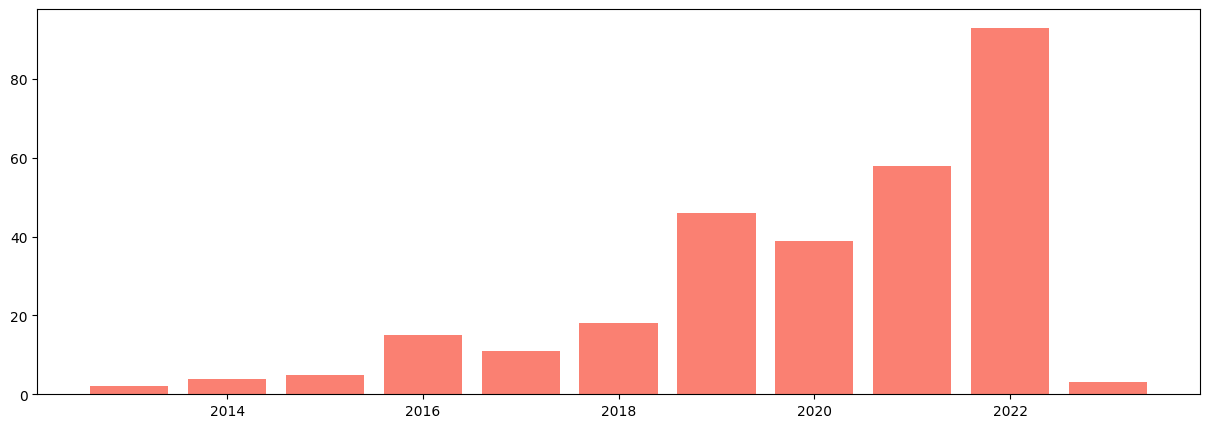

In [ ]:
plt.figure(figsize = (15,5))

plt.bar(x=vc.index,height=vc.values,color='salmon')

plt.show()

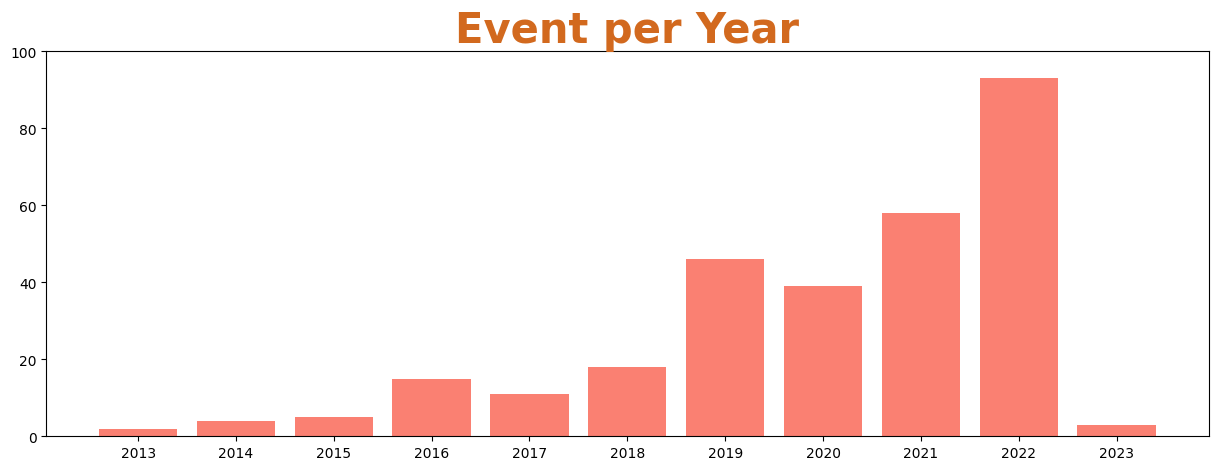

In [ ]:
plt.figure(figsize = (15,5))

plt.bar(height = vc.values, x = vc.index, color = "salmon")

plt.xticks(vc.index, vc.index)

#for i in vc.index:

  #plt.annotate(vc[i], xy = (i-0.05, vc[i]+2), size = 13)

plt.ylim(0,100)

plt.title("Event per Year", size = 30, color = "chocolate", weight = "heavy")

plt.show()

In [ ]:
vc = data.event_month.value_counts()

In [ ]:
vc

,count
event_month,
11,35
12,33
6,28
5,28
7,27
9,26
3,24
8,24
4,23


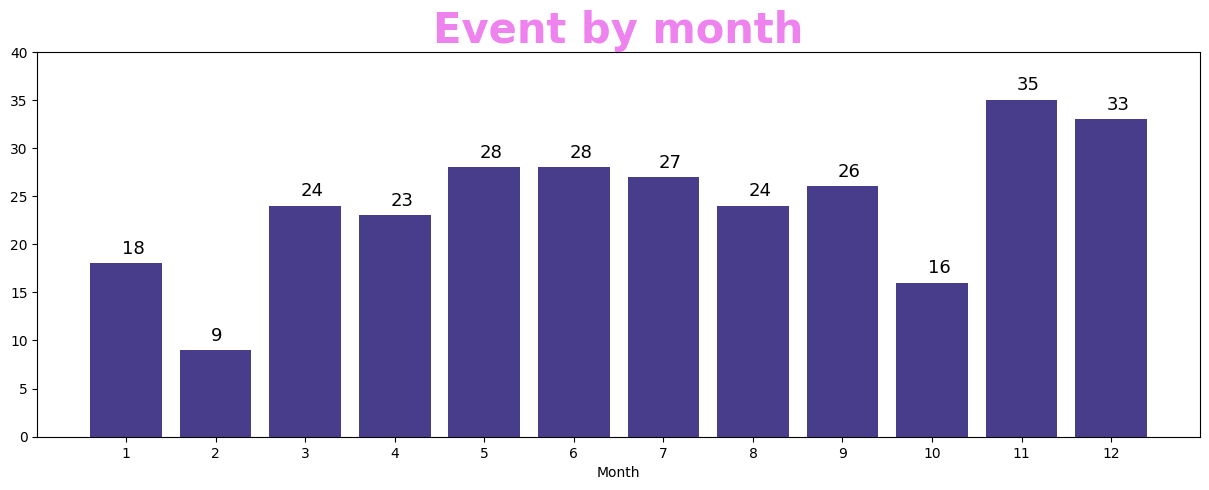

In [ ]:
plt.figure(figsize = (15,5))
plt.bar(height = vc.values, x = vc.index, color = "darkslateblue")
plt.xticks(vc.index, vc.index)
for i in vc.index:
  plt.annotate(vc[i], xy = (i-0.05, vc[i]+1), size = 13)
plt.ylim(0, 5 * round(vc.max()/5) +5)
plt.xlabel("Month")
plt.title("Event by month", size = 30, color = "violet",weight = "heavy")
plt.show()

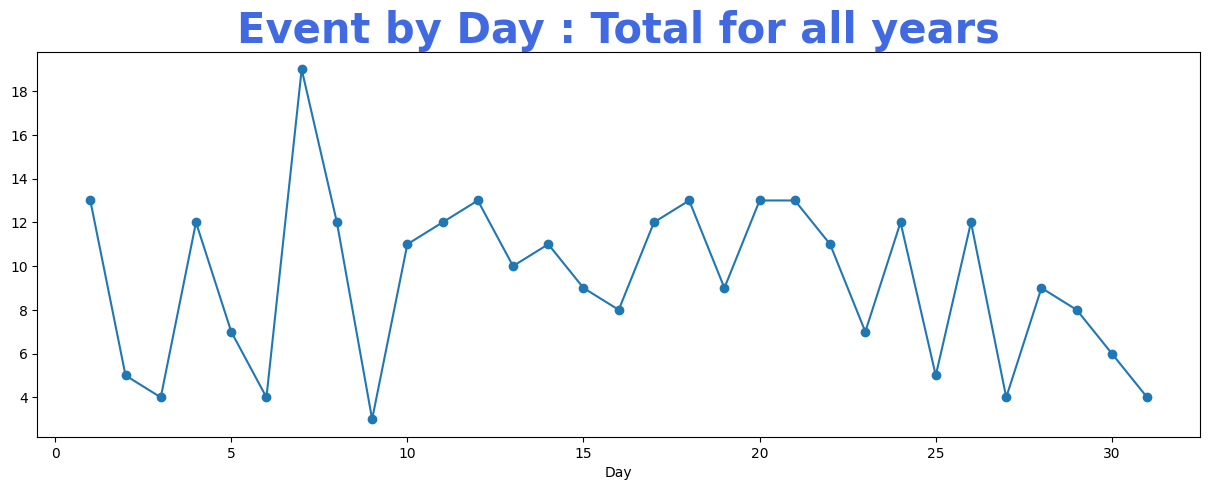

In [ ]:
vc = data.event_day.value_counts()
vc = vc.sort_index()
plt.figure(figsize = (15,5))
plt.plot( vc.index, vc.values)
plt.scatter( vc.index, vc.values)
plt.xlabel("Day")
plt.title("Event by Day : Total for all years", size = 30, color = "royalblue",weight = "heavy")
plt.show()

Conclusion : Tesla's accident volume tends to increase every year The number of accidents in November and December is the highest. Day wise no concrete info as the distribution pattern is irregular

In [ ]:
vc = data.Country.value_counts()

vc

,count
Country,
USA,213
China,16
Germany,11
Canada,9
Netherlands,6
UK,5
Norway,4
Holland,3
Switzerland,3


/tmp/ipython-input-1218244808.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(vc[i], xy = (i-0.1, vc[i]+2), size = 10)


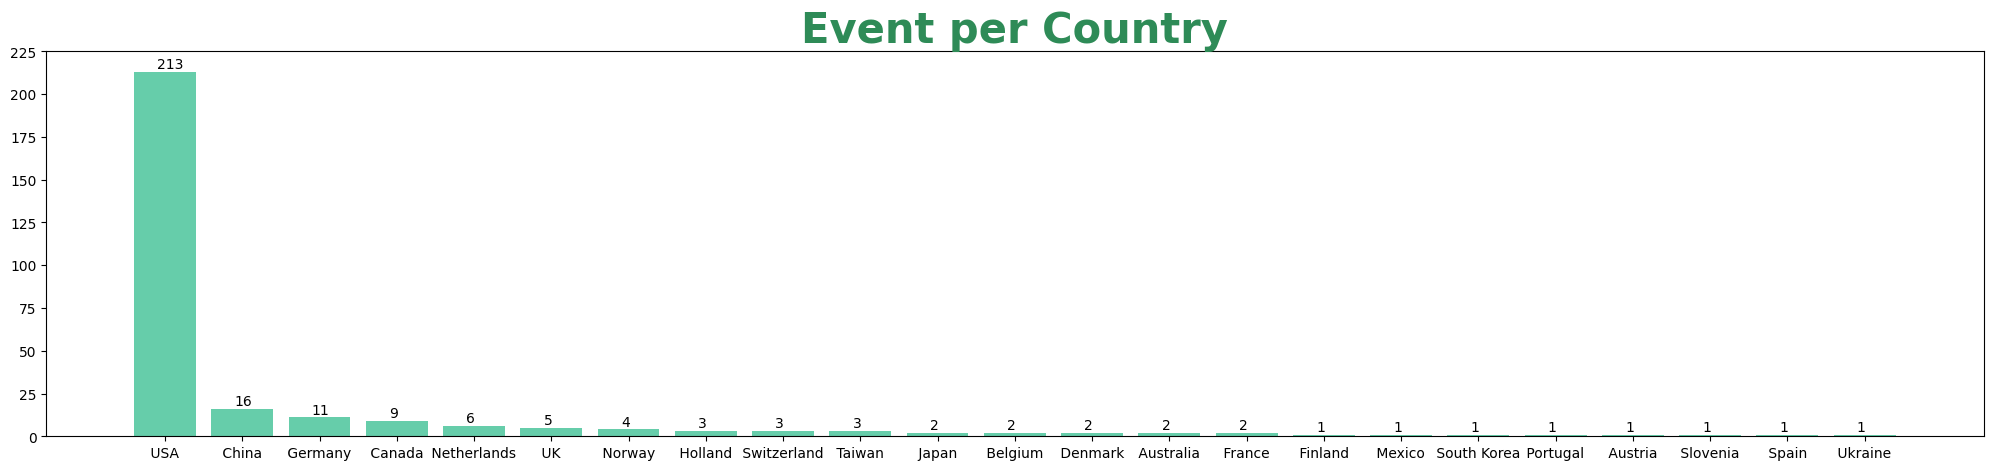

In [ ]:
vc = data.Country.value_counts()
plt.figure(figsize = (25,5))
plt.bar(height = vc.values, x = vc.index, color = "mediumaquamarine")
plt.xticks(vc.index, vc.index)
for i in range(len(vc.index)):
  plt.annotate(vc[i], xy = (i-0.1, vc[i]+2), size = 10)
plt.title("Event per Country", size = 30, color = "seagreen", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

In [ ]:
data.State = data.State.str.strip()

/tmp/ipython-input-4186117655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.State = data.State.str.strip()


In [ ]:
vc = data.State.value_counts()
vc = vc[vc.index != "-"]
vc

,count
State,
CA,90
FL,32
GA,9
AZ,8
PA,7
OH,6
NY,6
UT,5
NV,4


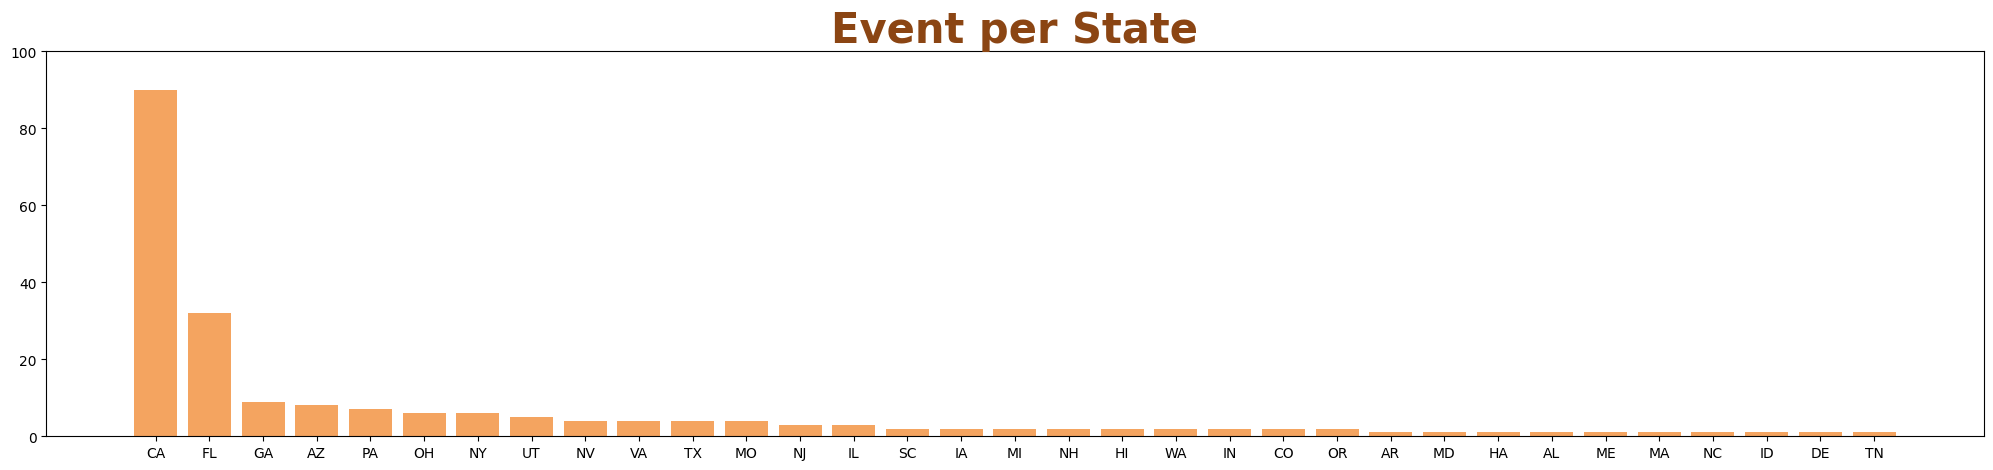

In [ ]:
plt.figure(figsize = (25,5))
plt.bar(height = vc.values, x = vc.index, color = "sandybrown")
plt.xticks(vc.index, vc.index)
plt.title("Event per State", size = 30, color = "saddlebrown", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

Analyse the different aspects of the death events. For example Compare the number of victims(deaths) in each accident.

In how many events the tesla driver died.

What is the proportion of events in which 1 or more occupants died ?

What is the distribution of events in which the vehicle hit a cyclist or a pedestrian ?

How many times did the accident involve the death of an occupant or driver of a Tesla along with a cyclist or pedestrian ?

What is the percentage of times tesla hit some other vehicle

In [ ]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists/Peds', 'TSLA+cycl/peds',
       'Model', 'Claimed', 'VTAD', 'event_year', 'event_month', 'event_day'],
      dtype='object')

In [ ]:
col_list = ['Deaths', 'Tesla_Driver','Tesla_Occupant', 'Other_Vehicle', 'Cyclists/Peds', 'TSLA+cycl/peds']

In [ ]:
colr = ['salmon', 'mediumaquamarine', 'mediumpurple', 'goldenrod', 'silver', 'saddlebrown']

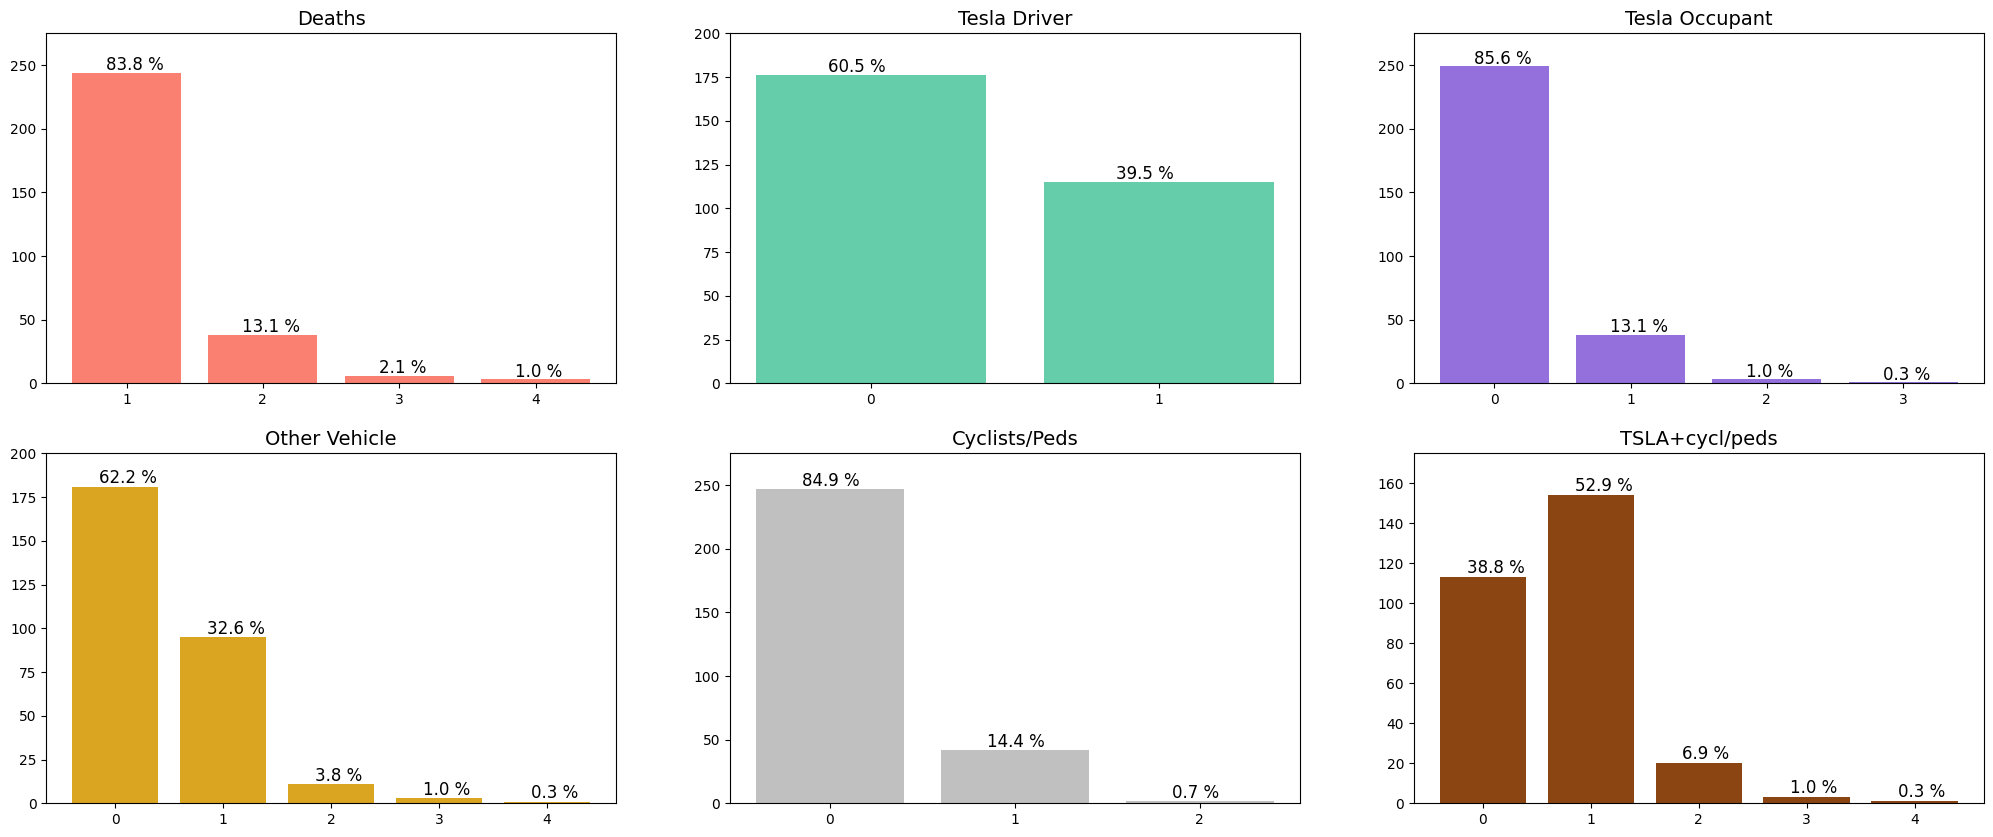

In [ ]:
f,ax = plt.subplots(2,3, figsize = (25,10))
i,j,k = 0,0,0
for col in col_list:
  vc = data[col].value_counts()
  vc = vc.sort_index()
  perc = (vc/vc.sum()*100).round(1)
  #print(vc)
  ax[i,j].bar(x = vc.index, height = vc.values, color = colr[k])
  ax[i,j].set_title(col.replace("_", " "), size = 14)
  ax[i,j].set_xticks(vc.index)
  for l in vc.index:
    #print(l)
    ax[i,j].annotate("{} %".format(perc[l]), xy = (l-0.15,vc[l]+2), size = 12)
    ax[i,j].set_ylim(0,  25 * round(vc.max()/25)+25)
  j += 1
  k += 1
  if j == 3:
    j = 0
    i += 1

Study the event distribution across models.

In [ ]:
data['Model']

,Model
3,-
4,-
5,-
6,-
7,-
...,...
289,-
290,-
291,-
292,-


In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
data.Model = data.Model.str.strip()

data.Model = data.Model.replace("-", "0")

In [ ]:

data['Model'].value_counts()

,count
Model,
0,178
S,45
3,39
X,17
Y,10
1,1
2,1


In [ ]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists/Peds', 'TSLA+cycl/peds',
       'Model', 'Claimed', 'VTAD', 'event_year', 'event_month', 'event_day'],
      dtype='object')

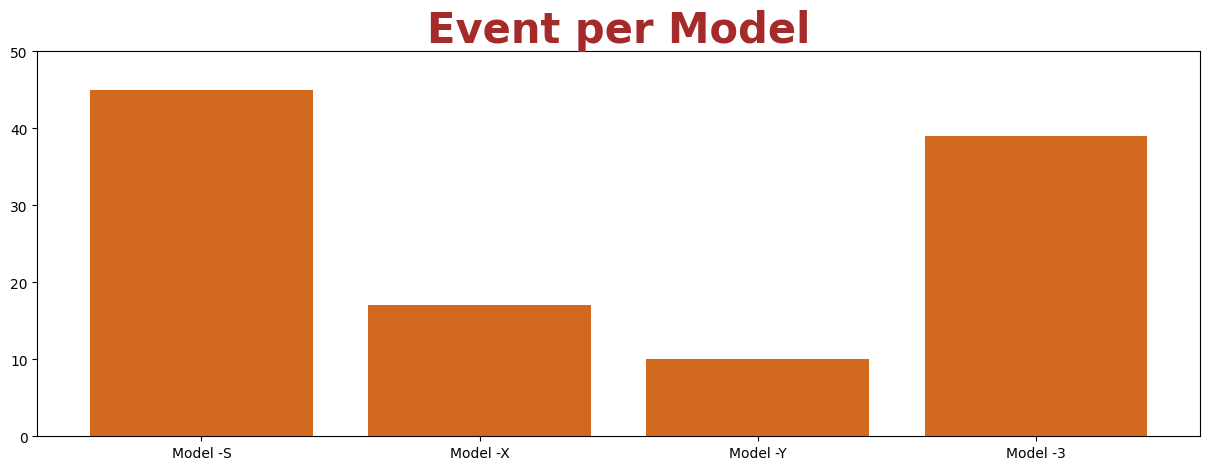

In [ ]:
vc = data.Model.value_counts()
vc = vc[["S", "X", "Y", "3"]]
plt.figure(figsize = (15,5))
plt.bar(height = vc.values, x = vc.index, color = "chocolate")
plt.xticks(vc.index, "Model -"+ vc.index.astype(str))
plt.title("Event per Model", size = 30, color = "brown", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

Check the distribution of Verified Tesla autopilot deaths.

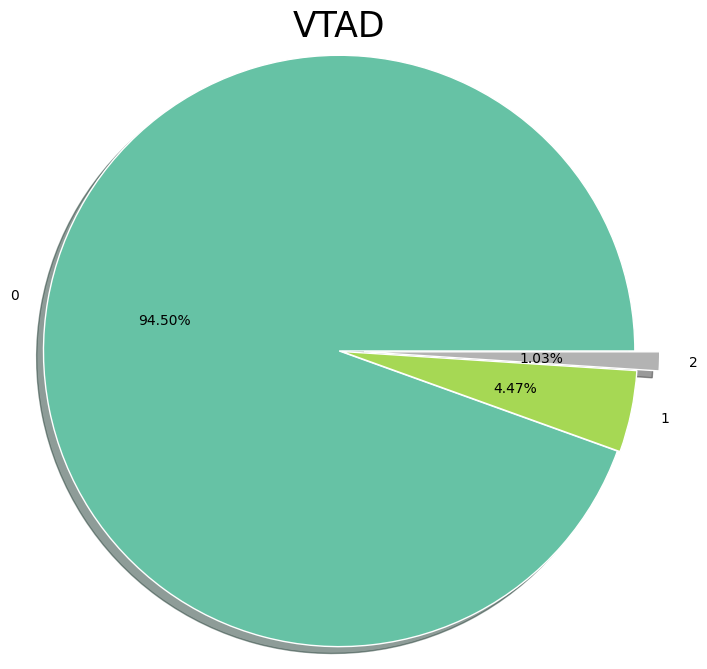

In [ ]:
vc = data.VTAD.value_counts()
plt.figure(figsize = (10,8))
vc.plot.pie(radius = 1.2, autopct = "%1.2f%%", shadow = True, wedgeprops = {'edgecolor':"white"}, cmap = 'Set2',
            explode = [0.001, 0.01,0.1])
plt.ylabel("")
plt.title("VTAD", pad = 5, size = 25)
plt.show()